In [2]:
import torch 
import torch.optim as optim 
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torchvision import transforms, models, datasets 

In [7]:
train_40X = "Final-40X\\train" 
val_40X = "Final-40X\\val"

train_100X = "Final-100X\\train" 
val_100X = "Final-100X\\val"

train_200X = "Final-200X\\train"
val_200X = "Final-200X\\val" 

train_400X = "Final-400X\\train"
val_400X = "Final-400X\\val" 

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [6]:
model = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
device = torch.device("cuda")


# Training on 40X Dataset without preprocessing

In [8]:
train_data = datasets.ImageFolder(train_40X, transform=transform)
val_data   = datasets.ImageFolder(val_40X, transform=transform)


In [9]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)


In [10]:
for param in model.features.parameters():
    param.requires_grad = False

In [11]:
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [12]:
model = model.to(device)

In [13]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [4]:
def train_model(model, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                outputs = torch.sigmoid(model(imgs))
                preds.extend((outputs.cpu().numpy() > 0.5).astype(int))
                true.extend(labels.numpy())

        acc = accuracy_score(true, preds)
        f1  = f1_score(true, preds)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")



In [15]:
train_model(model, epochs=15)

Epoch 1/15 | Loss: 0.6577 | Acc: 0.7073 | F1: 0.7260
Epoch 2/15 | Loss: 0.5804 | Acc: 0.7878 | F1: 0.7924
Epoch 2/15 | Loss: 0.5804 | Acc: 0.7878 | F1: 0.7924
Epoch 3/15 | Loss: 0.5235 | Acc: 0.8195 | F1: 0.8255
Epoch 3/15 | Loss: 0.5235 | Acc: 0.8195 | F1: 0.8255
Epoch 4/15 | Loss: 0.4785 | Acc: 0.8293 | F1: 0.8364
Epoch 4/15 | Loss: 0.4785 | Acc: 0.8293 | F1: 0.8364
Epoch 5/15 | Loss: 0.4426 | Acc: 0.8463 | F1: 0.8518
Epoch 5/15 | Loss: 0.4426 | Acc: 0.8463 | F1: 0.8518
Epoch 6/15 | Loss: 0.4172 | Acc: 0.8537 | F1: 0.8598
Epoch 6/15 | Loss: 0.4172 | Acc: 0.8537 | F1: 0.8598
Epoch 7/15 | Loss: 0.3918 | Acc: 0.8659 | F1: 0.8687
Epoch 7/15 | Loss: 0.3918 | Acc: 0.8659 | F1: 0.8687
Epoch 8/15 | Loss: 0.3790 | Acc: 0.8878 | F1: 0.8900
Epoch 8/15 | Loss: 0.3790 | Acc: 0.8878 | F1: 0.8900
Epoch 9/15 | Loss: 0.3652 | Acc: 0.8902 | F1: 0.8916
Epoch 9/15 | Loss: 0.3652 | Acc: 0.8902 | F1: 0.8916
Epoch 10/15 | Loss: 0.3415 | Acc: 0.8976 | F1: 0.9000
Epoch 10/15 | Loss: 0.3415 | Acc: 0.8976 | F1

In [16]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)


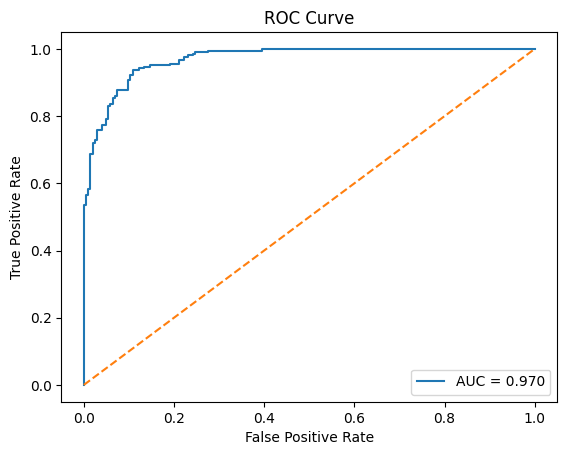

In [17]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


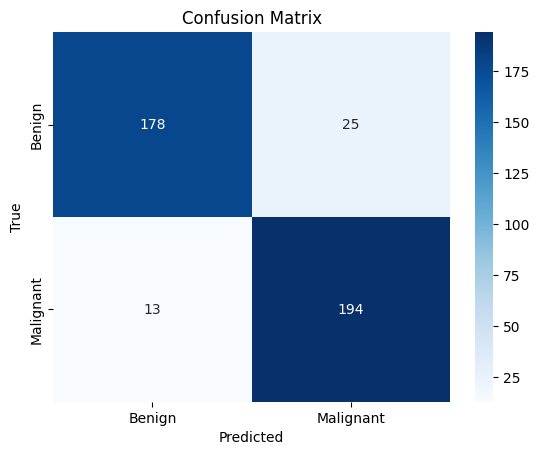

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [19]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.93      0.88      0.90       203
   Malignant       0.89      0.94      0.91       207

    accuracy                           0.91       410
   macro avg       0.91      0.91      0.91       410
weighted avg       0.91      0.91      0.91       410



In [20]:
torch.save(model.state_dict(), "Densenet40X.pth")
print("Model saved as Densenet40X.pth")


Model saved as Densenet40X.pth


# Training on 100X Dataset without preprocessing

In [5]:
train_data2 = datasets.ImageFolder(train_100X, transform=transform)
val_data2  = datasets.ImageFolder(val_100X, transform=transform)


NameError: name 'transform' is not defined

In [6]:
train_loader = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data2, batch_size=32, shuffle=False)


NameError: name 'train_data2' is not defined

In [23]:
fresh_model = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [24]:
for param in fresh_model.features.parameters():
    param.requires_grad = False

In [25]:
num_features = fresh_model.classifier.in_features
fresh_model.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [26]:
fresh_model = fresh_model.to(device)

In [27]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(fresh_model.parameters(), lr=1e-4)

In [1]:
train_model(fresh_model, epochs=15)

NameError: name 'train_model' is not defined

In [29]:
torch.save(fresh_model.state_dict(), "Densenet100X.pth")
print("Model saved as Densenet100X.pth")

Model saved as Densenet100X.pth


In [30]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
fresh_model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(fresh_model(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)


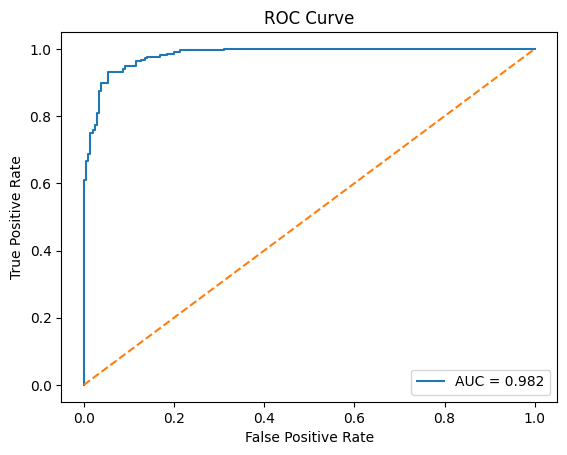

In [31]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


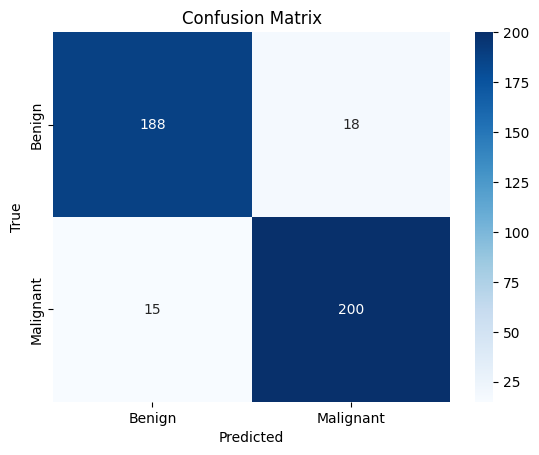

In [32]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [33]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.93      0.91      0.92       206
   Malignant       0.92      0.93      0.92       215

    accuracy                           0.92       421
   macro avg       0.92      0.92      0.92       421
weighted avg       0.92      0.92      0.92       421



# Training on 200X Dataset

In [34]:
train_data3 = datasets.ImageFolder(train_200X, transform=transform)
val_data3  = datasets.ImageFolder(val_200X, transform=transform)


In [35]:
train_loader = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data2, batch_size=32, shuffle=False)


In [36]:
fresh_model2 = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [37]:
for param in fresh_model2.features.parameters():
    param.requires_grad = False

In [38]:
num_features = fresh_model2.classifier.in_features
fresh_model2.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [39]:
fresh_model2 = fresh_model2.to(device)

In [40]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(fresh_model2.parameters(), lr=1e-4)

In [41]:
train_model(fresh_model2, epochs=15)

Epoch 1/15 | Loss: 0.6535 | Acc: 0.7197 | F1: 0.7204
Epoch 2/15 | Loss: 0.5777 | Acc: 0.8195 | F1: 0.8326
Epoch 2/15 | Loss: 0.5777 | Acc: 0.8195 | F1: 0.8326
Epoch 3/15 | Loss: 0.5243 | Acc: 0.8599 | F1: 0.8631
Epoch 3/15 | Loss: 0.5243 | Acc: 0.8599 | F1: 0.8631
Epoch 4/15 | Loss: 0.4769 | Acc: 0.8765 | F1: 0.8796
Epoch 4/15 | Loss: 0.4769 | Acc: 0.8765 | F1: 0.8796
Epoch 5/15 | Loss: 0.4451 | Acc: 0.8907 | F1: 0.8950
Epoch 5/15 | Loss: 0.4451 | Acc: 0.8907 | F1: 0.8950
Epoch 6/15 | Loss: 0.4193 | Acc: 0.8955 | F1: 0.8991
Epoch 6/15 | Loss: 0.4193 | Acc: 0.8955 | F1: 0.8991
Epoch 7/15 | Loss: 0.3975 | Acc: 0.8955 | F1: 0.9018
Epoch 7/15 | Loss: 0.3975 | Acc: 0.8955 | F1: 0.9018
Epoch 8/15 | Loss: 0.3759 | Acc: 0.8979 | F1: 0.9029
Epoch 8/15 | Loss: 0.3759 | Acc: 0.8979 | F1: 0.9029
Epoch 9/15 | Loss: 0.3610 | Acc: 0.9097 | F1: 0.9120
Epoch 9/15 | Loss: 0.3610 | Acc: 0.9097 | F1: 0.9120
Epoch 10/15 | Loss: 0.3422 | Acc: 0.9097 | F1: 0.9124
Epoch 10/15 | Loss: 0.3422 | Acc: 0.9097 | F1

In [42]:
torch.save(fresh_model2.state_dict(), "Densenet200X.pth")
print("Model saved as Densenet200X.pth")

Model saved as Densenet200X.pth


In [43]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
fresh_model2.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(fresh_model2(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)



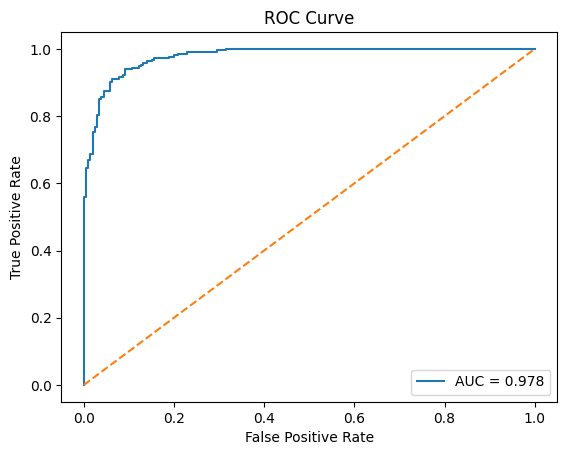

In [44]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


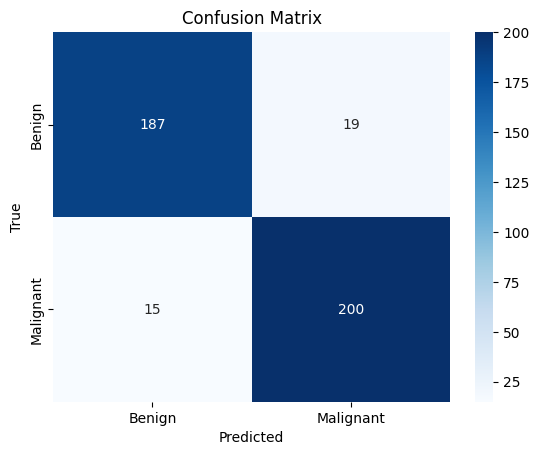

In [45]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [46]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.93      0.91      0.92       206
   Malignant       0.91      0.93      0.92       215

    accuracy                           0.92       421
   macro avg       0.92      0.92      0.92       421
weighted avg       0.92      0.92      0.92       421



# Training on 400X Dataset

In [9]:
train_data4 = datasets.ImageFolder(train_400X, transform=transform)
val_data4  = datasets.ImageFolder(val_400X, transform=transform)


In [10]:
train_loader = DataLoader(train_data4, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data4, batch_size=32, shuffle=False)


In [11]:
fresh_model3 = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
for param in fresh_model3.features.parameters():
    param.requires_grad = False

In [15]:
num_features = fresh_model3.classifier.in_features
fresh_model3.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

AttributeError: 'Sequential' object has no attribute 'in_features'

In [52]:
fresh_model3 = fresh_model3.to(device)

In [53]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(fresh_model3.parameters(), lr=1e-4)

In [ ]:
train_model(fresh_model3, epochs=15)

Epoch 1/15 | Loss: 0.1969 | Acc: 0.9492 | F1: 0.9502
Epoch 2/15 | Loss: 0.0600 | Acc: 0.9772 | F1: 0.9765
Epoch 2/15 | Loss: 0.0600 | Acc: 0.9772 | F1: 0.9765
Epoch 3/15 | Loss: 0.0205 | Acc: 0.9670 | F1: 0.9661
Epoch 3/15 | Loss: 0.0205 | Acc: 0.9670 | F1: 0.9661
Epoch 4/15 | Loss: 0.0116 | Acc: 0.9695 | F1: 0.9689
Epoch 4/15 | Loss: 0.0116 | Acc: 0.9695 | F1: 0.9689
Epoch 5/15 | Loss: 0.0209 | Acc: 0.9670 | F1: 0.9668
Epoch 5/15 | Loss: 0.0209 | Acc: 0.9670 | F1: 0.9668
Epoch 6/15 | Loss: 0.0107 | Acc: 0.9670 | F1: 0.9661
Epoch 6/15 | Loss: 0.0107 | Acc: 0.9670 | F1: 0.9661
Epoch 7/15 | Loss: 0.0046 | Acc: 0.9670 | F1: 0.9668
Epoch 7/15 | Loss: 0.0046 | Acc: 0.9670 | F1: 0.9668
Epoch 8/15 | Loss: 0.0039 | Acc: 0.9746 | F1: 0.9746
Epoch 8/15 | Loss: 0.0039 | Acc: 0.9746 | F1: 0.9746
Epoch 9/15 | Loss: 0.0052 | Acc: 0.9746 | F1: 0.9740
Epoch 9/15 | Loss: 0.0052 | Acc: 0.9746 | F1: 0.9740
Epoch 10/15 | Loss: 0.0073 | Acc: 0.9670 | F1: 0.9668
Epoch 10/15 | Loss: 0.0073 | Acc: 0.9670 | F1

In [ ]:
torch.save(fresh_model3.state_dict(), "Densenet400X.pth")
print("Model saved as Densenet400X.pth")

Model saved as Densenet400X.pth


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
fresh_model3.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(fresh_model3(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)



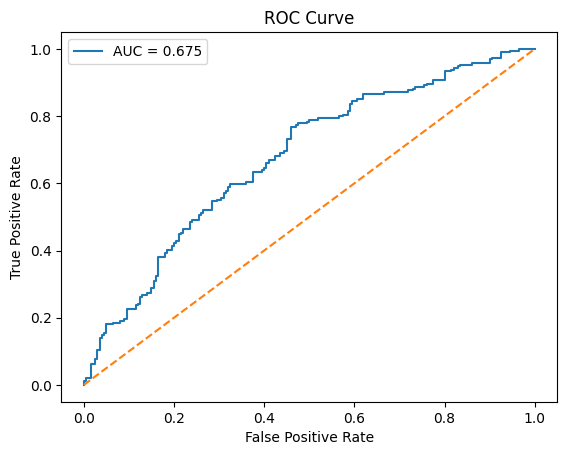

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


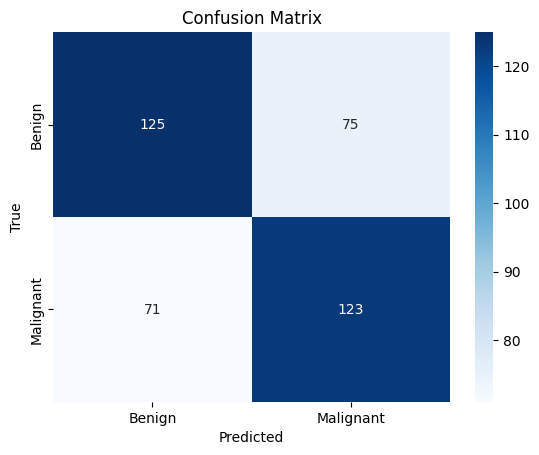

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.64      0.62      0.63       200
   Malignant       0.62      0.63      0.63       194

    accuracy                           0.63       394
   macro avg       0.63      0.63      0.63       394
weighted avg       0.63      0.63      0.63       394

